In [1]:
import pandas as pd
import numpy as np

In [2]:
TRAIN = "../data/train.csv"
TRAIN_SOUNDSCAPES_LABELS = "../data/train_soundscapes_labels.csv"
TAXONOMY = "../data/taxonomy.csv"
SAMPLE_SUBMISSION = "../data/sample_submission.csv"

In [3]:
train = pd.read_csv(TRAIN)
train_soundscapes_labels = pd.read_csv(TRAIN_SOUNDSCAPES_LABELS)
taxonomy = pd.read_csv(TAXONOMY)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION)

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   primary_label     35549 non-null  str    
 1   secondary_labels  35549 non-null  str    
 2   type              35549 non-null  str    
 3   latitude          35549 non-null  float64
 4   longitude         35549 non-null  float64
 5   scientific_name   35549 non-null  str    
 6   common_name       35549 non-null  str    
 7   class_name        35549 non-null  str    
 8   inat_taxon_id     35549 non-null  int64  
 9   author            35549 non-null  str    
 10  license           35549 non-null  str    
 11  rating            35549 non-null  float64
 12  url               35549 non-null  str    
 13  filename          35549 non-null  str    
 14  collection        35549 non-null  str    
dtypes: float64(3), int64(1), str(11)
memory usage: 4.1 MB


In [5]:
train_soundscapes_labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 1478 entries, 0 to 1477
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   filename       1478 non-null   str  
 1   start          1478 non-null   str  
 2   end            1478 non-null   str  
 3   primary_label  1478 non-null   str  
dtypes: str(4)
memory usage: 46.3 KB


In [6]:
taxonomy.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   primary_label    234 non-null    str  
 1   inat_taxon_id    234 non-null    int64
 2   scientific_name  234 non-null    str  
 3   common_name      234 non-null    str  
 4   class_name       234 non-null    str  
dtypes: int64(1), str(4)
memory usage: 9.3 KB


In [7]:
sample_submission.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Columns: 235 entries, row_id to yeofly1
dtypes: float64(234), str(1)
memory usage: 5.6 KB


In [8]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

from IPython.display import Audio

def plot_species_audio(data_dir, train_df, species_code, n_samples=1, rating=5.0):
    mask = (train_df['primary_label'] == species_code) & (train_df['rating'] == rating)
    species_samples = train_df[mask].head(n_samples)

    if species_samples.empty:
        print(f"Warning: No samples rated 5.0 for {species_code}. Searching for the best available...")
        species_samples = train_df[train_df['primary_label'] == species_code].sort_values('rating', ascending=False).head(n_samples)

    if species_samples.empty:
        print(f"Error: No sample found for the species: {species_code}")
        return

    for idx, row in species_samples.iterrows():
        file_path = os.path.join(data_dir, 'train_audio', row['filename'])
        
        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue

        print(f"--- Viewing: {species_code} (Rating: {row['rating']}) ---")

        y, sr = librosa.load(file_path, sr=32000)
        
        fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        
        # Wave
        librosa.display.waveshow(y, sr=sr, ax=ax[0], color='blue')
        ax[0].set_title(f'Waveform: {species_code} (Rating: {row["rating"]})')
        ax[0].set_ylabel('Amplitude')

        # Mel
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=16000)
        S_dB = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', 
                                      fmax=16000, ax=ax[1])
        ax[1].set_title(f'Mel-Spectrogram: {species_code}')
        fig.colorbar(img, ax=ax[1], format='%+2.0f dB')
        
        plt.tight_layout()
        plt.show()

Species selected for testing (Rating 5.0): 41970
--- Viewing: 41970 (Rating: 5.0) ---


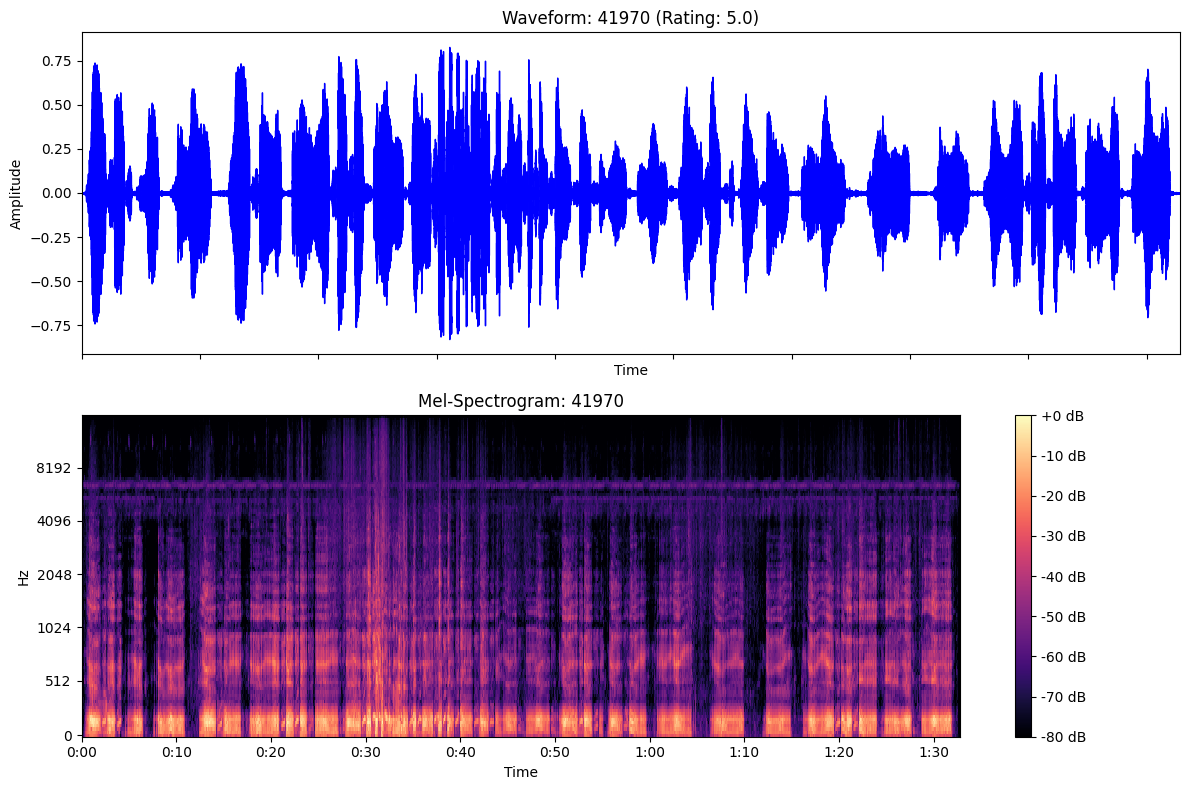

In [60]:
DATA_DIR = "../data"
train_metadata = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))

best_rated_samples = train_metadata[train_metadata['rating'] == 1.0]

if not best_rated_samples.empty:
    sample_species = best_rated_samples['primary_label'].iloc[0]
    print(f"Species selected for testing (Rating 5.0): {sample_species}")
else:
    sample_species = train_metadata['primary_label'].iloc[0]
    print(f"No samples with a score of 5.0 were found in the dataset. Testing with: {sample_species}")
    
plot_species_audio(DATA_DIR, train_metadata, sample_species)

Species selected for comparison: purjay1

>>> DISPLAYING MAXIMUM QUALITY (5.0)
--- Viewing: purjay1 (Rating: 5.0) ---


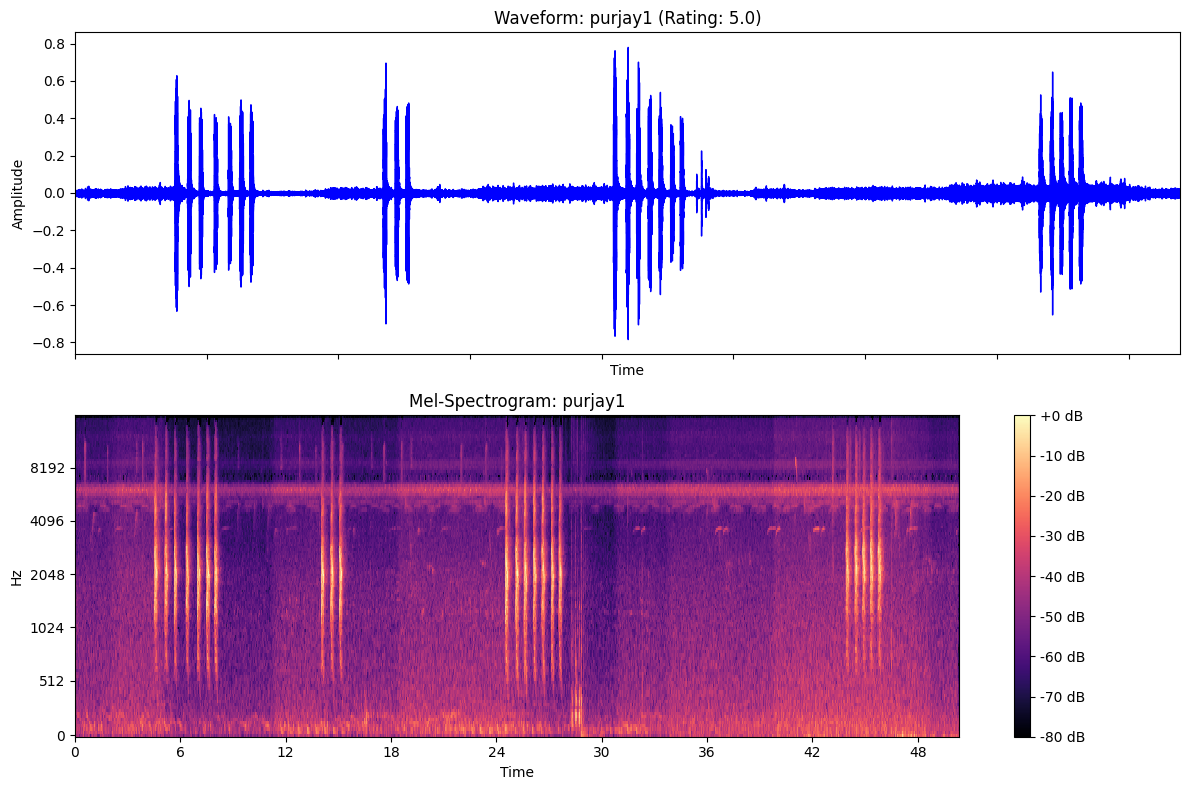


>>> DISPLAYING LOW QUALITY (<= 2.0)
--- Viewing: purjay1 (Rating: 0.0) ---


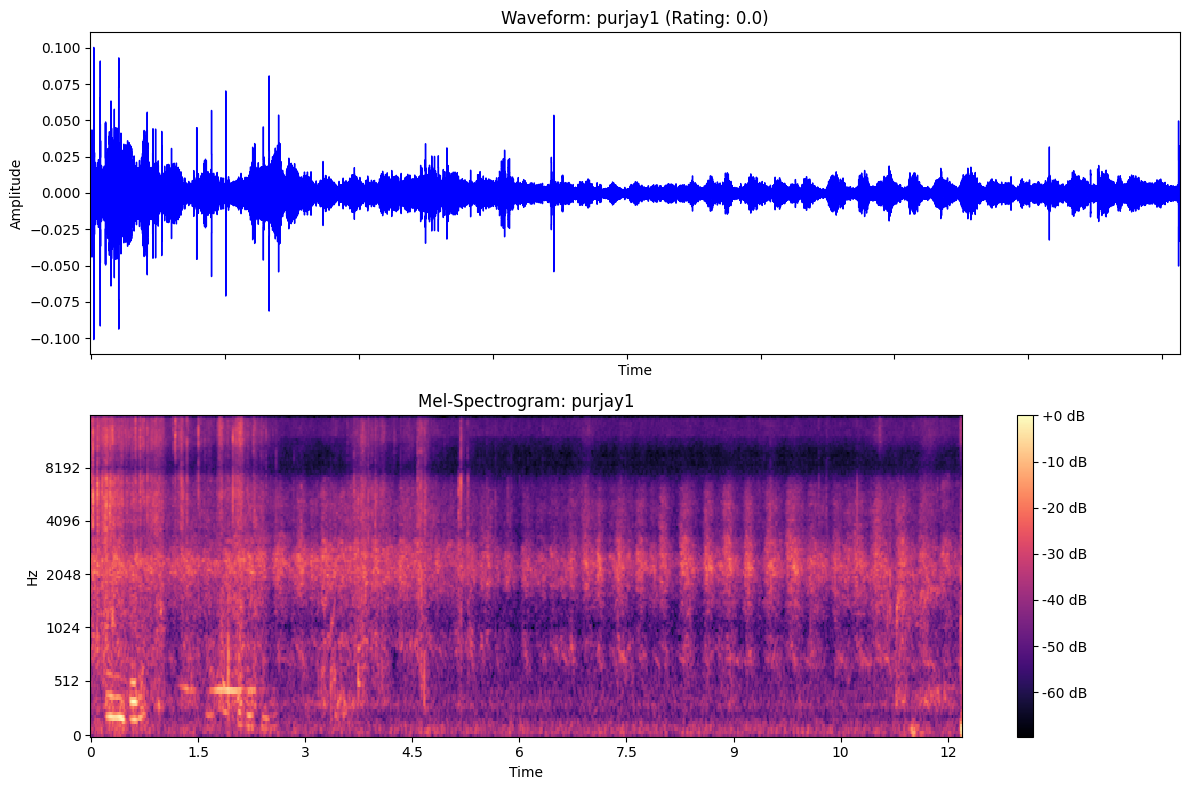

In [65]:
DATA_DIR = "../data"
train_metadata = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))

species_with_5 = set(train_metadata[train_metadata['rating'] == 5.0]['primary_label'])
species_with_low = set(train_metadata[train_metadata['rating'] <= 2.0]['primary_label'])

common_species = list(species_with_5.intersection(species_with_low))

if common_species:
    target = common_species[0]
    print(f"Species selected for comparison: {target}")
    
    print("\n>>> DISPLAYING MAXIMUM QUALITY (5.0)")
    plot_species_audio(DATA_DIR, train_metadata, target, rating=5.0)
    
    print("\n>>> DISPLAYING LOW QUALITY (<= 2.0)")
    low_rating = train_metadata[train_metadata['primary_label'] == target]['rating'].min()
    plot_species_audio(DATA_DIR, train_metadata, target, rating=low_rating)
else:
    sample_species = train_metadata['primary_label'].iloc[0]
    plot_species_audio(DATA_DIR, train_metadata, sample_species)

In [27]:
# TODO: analyze .value_counts()
df_to_analyze = train[[
    "primary_label",
    "common_name",
    "scientific_name",
    "class_name",
    "rating",
    "collection",
    "filename"
]]

df_to_analyze["primary_label"].value_counts() 

primary_label
rubthr1    499
banana     498
fepowl     497
soulap1    497
houspa     496
          ... 
70711        2
116570       1
23150        1
23724        1
516975       1
Name: count, Length: 206, dtype: int64

In [49]:
# TODO: analyze all numerical labels
string_numbers = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
numerical_labels = []

primary_label_list = df_to_analyze["primary_label"].to_list()
for label in primary_label_list:
    for num in string_numbers:
        if label.startswith(num):
            numerical_labels.append(label)

numerical_labels = set(numerical_labels)
numerical_labels = list(numerical_labels)

In [50]:
print("Numerical labels length: ", len(numerical_labels))

Numerical labels length:  44


In [52]:
df_primary_label = df_to_analyze[["primary_label"]]
df_primary_label[df_primary_label["primary_label"].isin(numerical_labels)].value_counts()

primary_label
244024           181
22973             63
24279             46
65377             46
47144             43
22956             32
326272            28
25092             26
23158             25
65380             23
41970             21
24285             19
555146            18
43435             14
67107             14
1176823           12
1161364           11
24287             11
22983             10
74113             10
555145             9
22967              8
760266             7
22930              6
22961              6
22985              6
67252              6
1595929            5
23154              5
66971              5
738183             5
23176              4
25214              3
476521             3
555123             3
64898              3
74580              3
209233             2
24321              2
70711              2
116570             1
23150              1
23724              1
516975             1
Name: count, dtype: int64

In [69]:
df_numerical_labels = df_to_analyze[df_to_analyze["primary_label"].isin(numerical_labels)]

df_numerical_labels["class_name"].value_counts(normalize=True)

class_name
Amphibia    0.601333
Insecta     0.265333
Mammalia    0.132000
Reptilia    0.001333
Name: proportion, dtype: float64

In [66]:
df_numerical_labels

,primary_label,common_name,scientific_name,class_name,rating,collection,filename
0,1161364,Guyalna cuta,Guyalna cuta,Insecta,0.0,iNat,1161364/iNat1216197.ogg
1,1161364,Guyalna cuta,Guyalna cuta,Insecta,0.0,iNat,1161364/iNat1114648.ogg
2,1161364,Guyalna cuta,Guyalna cuta,Insecta,0.0,iNat,1161364/iNat810195.ogg
3,1161364,Guyalna cuta,Guyalna cuta,Insecta,0.0,iNat,1161364/iNat818781.ogg
4,1161364,Guyalna cuta,Guyalna cuta,Insecta,0.0,iNat,1161364/iNat556514.ogg
...,...,...,...,...,...,...,...
745,760266,Prionacris erosa,Prionacris erosa,Insecta,0.0,iNat,760266/iNat382322.ogg
746,760266,Prionacris erosa,Prionacris erosa,Insecta,0.0,iNat,760266/iNat609771.ogg
747,760266,Prionacris erosa,Prionacris erosa,Insecta,0.0,iNat,760266/iNat175194.ogg
748,760266,Prionacris erosa,Prionacris erosa,Insecta,0.0,iNat,760266/iNat379362.ogg


60% are Amphibia — frogs, toads, and salamanders from the Pantanal. This changes everything: the problem isn't overlap with insect noise, it's that frogs and mammals have low-frequency vocalizations (100–2000 Hz), exactly the range that f_min=500 is cutting off. 555123 (3 samples), 476521 (3), 74580 (3), 1595929 (5) — all with ≤5 samples AND with f_min cutting off their signal.

In [84]:
# Which of the problems belong to which category?
problematic_label_list = ['555123', '22961', '476521', '1595929', '74580', '1176823', '67252']
df_to_analyze[df_to_analyze['primary_label'].isin(problematic_label_list)]\
    .groupby(['primary_label', 'class_name', 'common_name'])\
    .size().reset_index(name='count')

,primary_label,class_name,common_name,count
0,1176823,Amphibia,Wrestler Frog,12
1,1595929,Amphibia,Uruguay Harlequin Frog,5
2,22961,Amphibia,Pointedbelly Frog,6
3,476521,Amphibia,Cuyaba Dwarf Frog,3
4,555123,Amphibia,Usina Tree Frog,3
5,67252,Amphibia,Milk Frog,6
6,74580,Mammalia,Black-tailed Marmoset,3


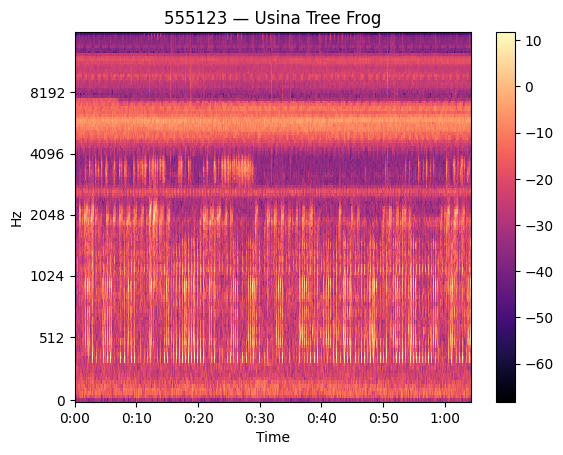

In [87]:
import librosa, librosa.display, matplotlib.pyplot as plt

row = df_to_analyze[df_to_analyze['primary_label'] == '555123'].iloc[0]
y, sr = librosa.load(f"../data/train_audio/{row['filename']}", sr=32000)
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmin=0, fmax=16000)
librosa.display.specshow(librosa.power_to_db(S), sr=sr, fmin=0, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title(f"555123 — {row['common_name']}")
plt.show()

In [75]:
df_to_analyze["class_name"].value_counts(normalize=True)

class_name
Aves        0.978902
Amphibia    0.012687
Insecta     0.005598
Mammalia    0.002785
Reptilia    0.000028
Name: proportion, dtype: float64

In [78]:
df_to_analyze["common_name"].to_list()

['Guyalna cuta',
 'Guyalna cuta',
 'Guyalna cuta',
 'Guyalna cuta',
 'Guyalna cuta',
 'Guyalna cuta',
 'Guyalna cuta',
 'Guyalna cuta',
 'Guyalna cuta',
 'Guyalna cuta',
 'Guyalna cuta',
 'Southern Spectacled Caiman',
 'Wrestler Frog',
 'Wrestler Frog',
 'Wrestler Frog',
 'Wrestler Frog',
 'Wrestler Frog',
 'Wrestler Frog',
 'Wrestler Frog',
 'Wrestler Frog',
 'Wrestler Frog',
 'Wrestler Frog',
 'Wrestler Frog',
 'Wrestler Frog',
 'Uruguay Harlequin Frog',
 'Uruguay Harlequin Frog',
 'Uruguay Harlequin Frog',
 'Uruguay Harlequin Frog',
 'Uruguay Harlequin Frog',
 'Feral Horse',
 'Feral Horse',
 'Basin White-lipped Frog',
 'Basin White-lipped Frog',
 'Basin White-lipped Frog',
 'Basin White-lipped Frog',
 'Basin White-lipped Frog',
 'Basin White-lipped Frog',
 'Mustached Frog',
 'Mustached Frog',
 'Mustached Frog',
 'Mustached Frog',
 'Mustached Frog',
 'Mustached Frog',
 'Mustached Frog',
 'Mustached Frog',
 'Mustached Frog',
 'Mustached Frog',
 'Mustached Frog',
 'Mustached Frog',
 'M

In [79]:
# What problems are amphibians/insects?
problem = ["555123","22961","1595929","476521","1176823","74580"]
df_to_analyze[
  df_to_analyze["primary_label"].isin(problem)
][[
  "primary_label","common_name",
  "class_name","rating"
]].drop_duplicates()

# How many samples does each one have?
df_to_analyze[
  df_to_analyze["primary_label"].isin(problem)
]["primary_label"].value_counts()

primary_label
1176823    12
22961       6
1595929     5
476521      3
555123      3
74580       3
Name: count, dtype: int64